<a href="https://colab.research.google.com/github/ekaterinam164-arch/HW_1/blob/main/HW_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Предварительная обработка, частоты и морфология в 'Мцыри'

In [112]:
# загружаем и скачиваем основные библиотеки
#pip install pymorphy3

import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
from collections import Counter
import matplotlib.pyplot as plt
from pymorphy3 import MorphAnalyzer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [113]:
# импортируем текст
import requests
url = 'https://raw.githubusercontent.com/ekaterinam164-arch/HW_1/refs/heads/main/text.txt'

response = requests.get(url)
text = response.text

# Задание 1: Регулярные выражения
Напишите регулярное выражение, которое найдет все слова, начинающиеся с "ста".
1. Расширьте: найдите слова с "ста" внутри (не только в начале).
2. Модернизируйте: сделайте 'т' опциональной (замените на любой символ: [а-ят]?).

Ожидаемый вывод: список найденных слов, например, ['старик', 'старый'].

In [114]:
print(re.findall(r'\bста\w+', text, re.IGNORECASE))
print(re.findall(r'\b\w*ста\w+', text, re.IGNORECASE))
print(re.findall(r'\b\w*с[а-ят]?а\w+', text, re.IGNORECASE))

['старик', 'Стал', 'стал', 'Старик', 'старик', 'старик', 'стало', 'стариков', 'старости', 'стало', 'стал', 'стал', 'стал', 'стал', 'стал', 'старик', 'стал', 'стал', 'стало', 'стада', 'стану', 'стану']
['старик', 'остался', 'Стал', 'стал', 'Привстал', 'остаток', 'Старик', 'старик', 'расстаться', 'старик', 'стало', 'стариков', 'старости', 'устав', 'стало', 'стал', 'кустам', 'стал', 'стал', 'Простая', 'настает', 'стал', 'стал', 'старик', 'Встал', 'стал', 'остаток', 'стал', 'стало', 'Оставила', 'усталую', 'кустах', 'встать', 'хрусталь', 'стада', 'Останься', 'усталый', 'остальное', 'стану', 'стану']
['старик', 'славе', 'садов', 'опасаяся', 'слаб', 'слабый', 'остался', 'спасен', 'Сначала', 'Стал', 'слаб', 'стал', 'Привстал', 'остаток', 'рассказать', 'скалы', 'Старик', 'спас', 'сказать', 'старик', 'сладостных', 'расстаться', 'Пускай', 'слаб', 'старик', 'скал', 'стало', 'стариков', 'сладостных', 'касалися', 'Рассказы', 'старости', 'Скажи', 'устав', 'сжал', 'сам', 'стало', 'скал', 'сад', 'стал'

# Задание 2: Нормализация текста

1. Приведите текст к нижнему регистру.
2. Удалите пунктуацию и \n с помощью regex (используйте `re.sub(r'[^а-яё\s]', ' ', text.lower())` как основу).

Сохраните нормализованный текст в `normalized_text`.

In [115]:
normalized_text = re.sub(r'[^а-яё\s-]', '', text.lower())
normalized_text = re.sub(r'\n+', ' ', normalized_text)
normalized_text = re.sub(r'-', ' ', normalized_text)
normalized_text

' немного лет тому назад там где сливаяся шумят обнявшись будто две сестры струи арагвы и куры был монастырь из за горы и нынче видит пешеход столбы обрушенных ворот и башни и церковный свод но не курится уж под ним кадильниц благовонный дым не слышно пенье в поздний час молящих иноков за нас теперь один старик седой развалин страж полуживой людьми и смертию забыт сметает пыль с могильных плит которых надпись говорит о славе прошлой  и о том как удручен своим венцом такой то царь в такой то год вручал россии свой народ и божья благодать сошла на грузию она цвела с тех пор в тени своих садов не опасаяся врагов за гранью дружеских штыков однажды русский генерал из гор к тифлису проезжал ребенка пленного он вез тот занемог не перенес трудов далекого пути он был казалось лет шести как серна гор пуглив и дик и слаб и гибок как тростник но в нем мучительный недуг развил тогда могучий дух его отцов без жалоб он томился даже слабый стон из детских губ не вылетал он знаком пищу отвергал и тихо 

## Задание 3: Токенизация

1. Токенизируйте `normalized_text` на слова (используйте `re.findall(r'\w+', normalized_text)`). Подсчитайте общее число токенов и уникальных (используйте `set` или `Counter`).
2. Токенизируйте оригинальный `text` на строки (`split('\n')`). Сколько строк?
3. Напишите цикл: сохраните слова с заглавной буквы (из оригинального текста).
4. Модернизируйте цикл: исключите первые слова строк (используйте `line.split()` и проверку позиции).

Ожидаемый вывод: len(tokens), len(set(tokens)), список имен/заголовков.

In [ ]:
tokens = re.findall(r'\w+', normalized_text)
print(len(tokens))
print(len(set(tokens)))

3353
1661


In [ ]:
lines = text.split('\n')
print(len(lines))

803


In [ ]:
all_capitalized = []
pattern = r'\b[А-ЯЁ]\w+'

for word in text.split():
    if re.match(pattern, word):
        all_capitalized.append(word)

print(all_capitalized)

['Немного', 'Там,', 'Обнявшись,', 'Струи', 'Арагвы', 'Куры,', 'Был', 'Из-за', 'Столбы', 'Но', 'Кадильниц', 'Не', 'Молящих', 'Теперь', 'Развалин', 'Людьми', 'Сметает', 'Которых', 'Как,', 'Такой-то', 'Вручал', 'России', 'На', 'Грузию!', 'Она', 'Не', 'За', 'Однажды', 'Из', 'Тифлису', 'Ребенка', 'Тот', 'Трудов', 'Он', 'Как', 'Но', 'Развил', 'Его', 'Без', 'Томился,', 'Из', 'Он', 'Из', 'Больного', 'Хранительных', 'Искусством', 'Но,', 'Сначала', 'Бродил', 'Смотрел,', 'Томим', 'По', 'Но', 'Стал', 'Был', 'Уже', 'Изречь', 'Как', 'Осенней', 'Темный', 'Тянулся', 'Три', 'Напрасны', 'Его', 'Он', 'Болезнь', 'Он', 'Тогда', 'Привстал,', 'Сюда', 'Все', 'Словами', 'Но', 'Немного', 'Таких', 'Но', 'Одну', 'Она,', 'Изгрызла', 'Она', 'От', 'Где', 'Где', 'Вскормил', 'Ее', 'Старик!', 'Что', 'Зачем?..', 'Угрюм', 'Грозой', 'Душой', 'Священных', 'Конечно,', 'Чтоб', 'От', 'Напрасно:', 'Со', 'Отчизну,', 'Не', 'Тогда,', 'Хотя', 'Мою', 'Прижать', 'Хоть', 'Увы!', 'Погибли', 'Умру', 'Меня', 'Там,', 'Но', 'Знал', 'Разгу

In [ ]:
capitalized = []
pattern = r'\b[А-ЯЁ]\w+'

for line in text.splitlines():
  words = re.findall(pattern, line)
  for word in words[1:]:
    capitalized.append(word)

print(capitalized)

['Арагвы', 'Куры', 'Из', 'России', 'Грузию', 'Она', 'Тифлису', 'Без', 'Темный', 'Угрюм', 'Ты', 'Пышные', 'Кавказ', 'Жил', 'Бледный', 'Хотя', 'Из', 'Порой', 'Летние', 'Помню', 'Лишь', 'Вдруг', 'Сырую', 'Он', 'Вдали', 'Смутный', 'Напрасно', 'Таков', 'Едва', 'Мир', 'Лишь', 'Сквозь', 'Арагва', 'Кура', 'Чешуей', 'Она', 'Дитя', 'Божий', 'Кавказ']


## Задание 4: Удаление стоп-слов

1. Импортируйте стоп-слова NLTK для русского.
2. Создайте список токенов без стоп-слов (цикл или list comprehension).
3. Подсчитайте оставшиеся токены и уникальные.
4. Добавьте к стоп-словам слова с 'бол' (опциональная 'о': regex `r'\w*б[о]?л\w*'`). Удалите их. Сколько осталось?

Сохраните в `filtered_tokens`.

In [ ]:
stopwords_ru = stopwords.words('russian')
filtered_tokens = [token for token in word_tokenize(normalized_text) if token not in stopwords_ru]

print(len(filtered_tokens))
print(len(set(filtered_tokens)))

2139
1537


In [ ]:
filtered_tokens = [token for token in filtered_tokens if not re.match(r'\w*б[о]?л\w*', token)]
print(len(filtered_tokens))
print(len(set(filtered_tokens)))

2109
1513


## Задание 5: Частотный анализ

1. Используйте `Counter` на `filtered_tokens`: выведите топ-10 самых частых слов.
2. Визуализируйте: Постройте барчарт топ-10 (matplotlib: `plt.bar()`). Подпишите оси ('Слова', 'Частота').
3. Гуманитарная интерпретация: Разделите текст на две главы (используйте индекс поиска 'Глава 2' или вручную). Сравните топ-5 частых слов в каждой (Counter для каждой главы). Что это говорит о темах? (Например, в первой — 'монастырь/плен', во второй — 'свобода/бег').

*Ожидаемый вывод: Таблица сравнения (используйте pandas.DataFrame для топ-5).*

In [ ]:
freq = Counter(filtered_tokens)
print(freq.most_common(10))

[('лишь', 12), ('мог', 11), ('грудь', 10), ('мной', 10), ('меж', 10), ('стал', 9), ('долго', 8), ('мою', 8), ('жил', 8), ('б', 8)]


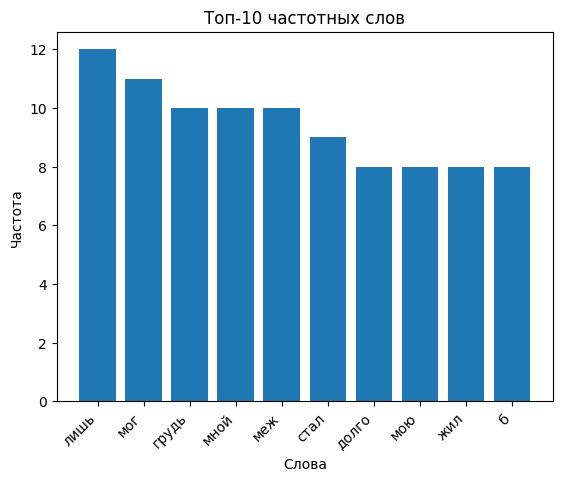

In [ ]:
words = [item[0] for item in freq.most_common(10)]
counts = [item[1] for item in freq.most_common(10)]

plt.bar(words, counts)
plt.xlabel('Слова')
plt.ylabel('Частота')
plt.title('Топ-10 частотных слов')
plt.xticks(rotation=45, ha='right')
plt.show()

In [116]:
chapter_1 = re.split(r'\n?\d+\n?', text)[1] #использую такой индекс, потому что при разрезании текста 1 элемент почему-то остается пустым
chapter_2 = re.split(r'\n?\d+\n?', text)[2]

normalized_chapter_1 = re.sub(r'[^а-яё\s-]', '', chapter_1.lower())
normalized_chapter_1 = re.sub('\n+', ' ', normalized_chapter_1)
normalized_chapter_1 = re.sub('-', ' ', normalized_chapter_1)

normalized_chapter_2 = re.sub(r'[^а-яё\s-]', '', chapter_2.lower())
normalized_chapter_2 = re.sub('\n+', ' ', normalized_chapter_2)
normalized_chapter_2 = re.sub('-', ' ', normalized_chapter_2)

In [ ]:
import pandas as pd

In [ ]:
tokens_chapter_1 = [token for token in word_tokenize(normalized_chapter_1) if token not in stopwords_ru]
tokens_chapter_2 = [token for token in word_tokenize(normalized_chapter_2) if token not in stopwords_ru]

freq_1 = Counter(tokens_chapter_1)
freq_2 = Counter(tokens_chapter_2)

words_1 = [item[0] for item in freq_1.most_common(5)]
counts_1 = [item[1] for item in freq_1.most_common(5)]

words_2 = [item[0] for item in freq_2.most_common(5)]
counts_2 = [item[1] for item in freq_2.most_common(5)]

df = pd.DataFrame({'Глава 1': words_1,
                   'Частота 1': counts_1,
                   'Глава 2': words_2,
                   'Частота 2': counts_2})
df

,Глава 1,Частота 1,Глава 2,Частота 2
0,немного,1,однажды,2
1,лет,1,гор,2
2,тому,1,лет,2
3,назад,1,слаб,2
4,сливаяся,1,нем,2


## Задание 6: Морфологический анализ

1. Инициализируйте `MorphAnalyzer` из pymorphy2. Проанализируйте POS (часть речи) для топ-10 частых слов из Задания 5 (`.tag.POS` или `.parse(word)[0].tag.POS`).
2. Создайте Counter для частей речи во всем `filtered_tokens` (цикл: для каждого токена — morph.parse(word)[0].tag.POS). Выведите топ-3 (существительные? глаголы?).
3. Найдите все глаголы движения ('бежать', 'мчаться' и т.п. — используйте regex `r'\b[бмп]е[жз]у?\w*'`) и их формы (morph.normal_form). Сколько уникальных лемм? Как это отражает тему 'побега' в 'Мцыри'?

*Ожидаемый вывод: Словарь {POS: count}, список лемм глаголов.*

In [145]:
morph = MorphAnalyzer(lang = 'ru')

for word in words:
  pos = morph.parse(word)[0].tag.POS
  print(f'{word} — {pos}')

лишь — PRCL
мог — VERB
грудь — NOUN
мной — NPRO
меж — PREP
стал — VERB
долго — ADVB
мою — ADJF
жил — VERB
б — PRCL


In [146]:
Counter([morph.parse(word)[0].tag.POS for word in filtered_tokens]).most_common(3)

[('NOUN', 881), ('VERB', 403), ('ADJF', 389)]

## Задание 7: Интеграция и интерпретация

1. Соберите пайплайн: Обработайте полный текст (объедините главы), создайте 'чистый' корпус (нормализация + фильтрация + лемматизация с pymorphy2). В этом случае можно использовать нестандартные решения, которые мы изучали бегло или только упоминали.
2. Сравнительный анализ: Вычислите TF-IDF для двух глав (используйте простой расчет: freq_in_doc / log(total_docs / docs_with_word)). Выведите топ-3 уникальных слова для каждой главы.
3. Визуализация стиля: Постройте word cloud. Сравните облака для глав.
4. Вывод: В 100–200 словах опишите, как обработка раскрывает романтизм Лермонтова (контраст 'плена' и 'свободы').

In [76]:
# функция для очистки и лемматизации текста

def lemmatization(full_text):
  clear_text = re.sub(r'[^а-яё\s-]', '', full_text.lower())
  clear_text = re.sub(r'\n+', ' ', clear_text)
  clear_text = re.sub(r'-', ' ', clear_text)

  text_tokens = [token for token in word_tokenize(clear_text) if token not in stopwords_ru]

  lemmas = [morph.parse(token)[0].normal_form for token in text_tokens]

  return lemmas

In [77]:
lemmatization(text)

['немного',
 'год',
 'тот',
 'назад',
 'сливаясь',
 'шуметь',
 'обняться',
 'два',
 'сестра',
 'струить',
 'арагва',
 'кура',
 'монастырь',
 'гора',
 'нынче',
 'видеть',
 'пешеход',
 'столб',
 'обрушить',
 'ворота',
 'башня',
 'церковный',
 'свод',
 'куриться',
 'кадильница',
 'благовонный',
 'дым',
 'слышный',
 'пение',
 'поздний',
 'час',
 'молить',
 'инок',
 'старик',
 'седой',
 'развалины',
 'страж',
 'полуживой',
 'человек',
 'смертие',
 'забытый',
 'сметать',
 'пыль',
 'могильный',
 'плита',
 'который',
 'надпись',
 'говорить',
 'слава',
 'прошлый',
 'удручённый',
 'свой',
 'венец',
 'царь',
 'год',
 'вручать',
 'россия',
 'свой',
 'народ',
 'божий',
 'благодать',
 'сойти',
 'грузия',
 'цвести',
 'тот',
 'пора',
 'тень',
 'свой',
 'сад',
 'опасаясь',
 'враг',
 'грань',
 'дружеский',
 'штык',
 'однажды',
 'русский',
 'генерал',
 'гора',
 'тифлис',
 'проезжать',
 'ребёнок',
 'пленный',
 'везти',
 'занемочь',
 'перенести',
 'труд',
 'далёкий',
 'путь',
 'казаться',
 'год',
 'шесть',

In [91]:
# делим целый текст на главы
chapters = [chapter.strip() for chapter in re.split(r'\n?\d+', text) if chapter.strip()]

# применяем функцию для очистки и лемматизации отдельно по главам
clean_chapters = [lemmatization(chapter) for chapter in chapters]

In [117]:
clean_chapters

[['немного',
  'год',
  'тот',
  'назад',
  'сливаясь',
  'шуметь',
  'обняться',
  'два',
  'сестра',
  'струить',
  'арагва',
  'кура',
  'монастырь',
  'гора',
  'нынче',
  'видеть',
  'пешеход',
  'столб',
  'обрушить',
  'ворота',
  'башня',
  'церковный',
  'свод',
  'куриться',
  'кадильница',
  'благовонный',
  'дым',
  'слышный',
  'пение',
  'поздний',
  'час',
  'молить',
  'инок',
  'старик',
  'седой',
  'развалины',
  'страж',
  'полуживой',
  'человек',
  'смертие',
  'забытый',
  'сметать',
  'пыль',
  'могильный',
  'плита',
  'который',
  'надпись',
  'говорить',
  'слава',
  'прошлый',
  'удручённый',
  'свой',
  'венец',
  'царь',
  'год',
  'вручать',
  'россия',
  'свой',
  'народ',
  'божий',
  'благодать',
  'сойти',
  'грузия',
  'цвести',
  'тот',
  'пора',
  'тень',
  'свой',
  'сад',
  'опасаясь',
  'враг',
  'грань',
  'дружеский',
  'штык'],
 ['однажды',
  'русский',
  'генерал',
  'гора',
  'тифлис',
  'проезжать',
  'ребёнок',
  'пленный',
  'везти',
  '

In [107]:
#пишем функцию для подсчета TF-IDF
import math

def tfidf(all_chapters):
  all_docs = len(all_chapters)

  unique_words_chapter = [set(chapter) for chapter in all_chapters]
  all_unique_words = [word for chapter_words in unique_words_chapter for word in chapter_words]

  doc_freq = Counter(all_unique_words)

  tf_idf = []

  for chapter in all_chapters:
        tf = Counter(chapter)
        total_terms = len(chapter)

        chapter_tfidf = {}
        for word, freq in tf.items():
            tf_value = freq / total_terms
            idf_value = math.log(all_docs / doc_freq[word])
            tfidf_value = tf_value * idf_value
            chapter_tfidf[word] = tfidf_value

        tf_idf.append(chapter_tfidf)

  return tf_idf

# собираем TF-IDF по всем главам
tfidf_by_chapter = tfidf(clean_chapters)

In [108]:
tfidf_by_chapter

[{'немного': 0.034661477803534284,
  'год': 0.03963073158901154,
  'тот': 0.03546449699908564,
  'назад': 0.034661477803534284,
  'сливаясь': 0.044028331594884895,
  'шуметь': 0.029182219585856383,
  'обняться': 0.029182219585856383,
  'два': 0.01981536579450577,
  'сестра': 0.029182219585856383,
  'струить': 0.044028331594884895,
  'арагва': 0.034661477803534284,
  'кура': 0.034661477803534284,
  'монастырь': 0.034661477803534284,
  'гора': 0.022279170616045698,
  'нынче': 0.034661477803534284,
  'видеть': 0.01773224849954282,
  'пешеход': 0.044028331594884895,
  'столб': 0.034661477803534284,
  'обрушить': 0.044028331594884895,
  'ворота': 0.044028331594884895,
  'башня': 0.034661477803534284,
  'церковный': 0.044028331594884895,
  'свод': 0.034661477803534284,
  'куриться': 0.034661477803534284,
  'кадильница': 0.044028331594884895,
  'благовонный': 0.044028331594884895,
  'дым': 0.044028331594884895,
  'слышный': 0.044028331594884895,
  'пение': 0.044028331594884895,
  'поздний': 0

In [110]:
# сортируем и выводим топ-3 самых часто встречаемых слов во всех главах

top3_words = []

for i in range(len(tfidf_by_chapter)):
  top_words = sorted(tfidf_by_chapter[i].items(), key=lambda x: x[1], reverse=True)[:3]

  for word, tfidf in top_words:
    top3_words.append({
        'Глава': f'Глава {i + 1}',
        'Слово': word,
        'TF-IDF': tfidf
    })

df_top_words = pd.DataFrame(top3_words)
df_top_words

,Глава,Слово,TF-IDF
0,Глава 1,свой,0.047783
1,Глава 1,сливаясь,0.044028
2,Глава 1,струить,0.044028
3,Глава 2,однажды,0.046214
4,Глава 2,гордо,0.046214
...,...,...,...
73,Глава 25,прощать,0.069321
74,Глава 25,пламень,0.069321
75,Глава 26,прислать,0.090503
76,Глава 26,вели,0.059986


In [125]:
# сортируем TF-IDF во всех главах и вносим их в единый список, чтобы на его основе создать облака

sorted_tfidf = [sorted(tfidf_by_chapter[i].items(), key=lambda x: x[1], reverse=True) for i in range(len(tfidf_by_chapter))]

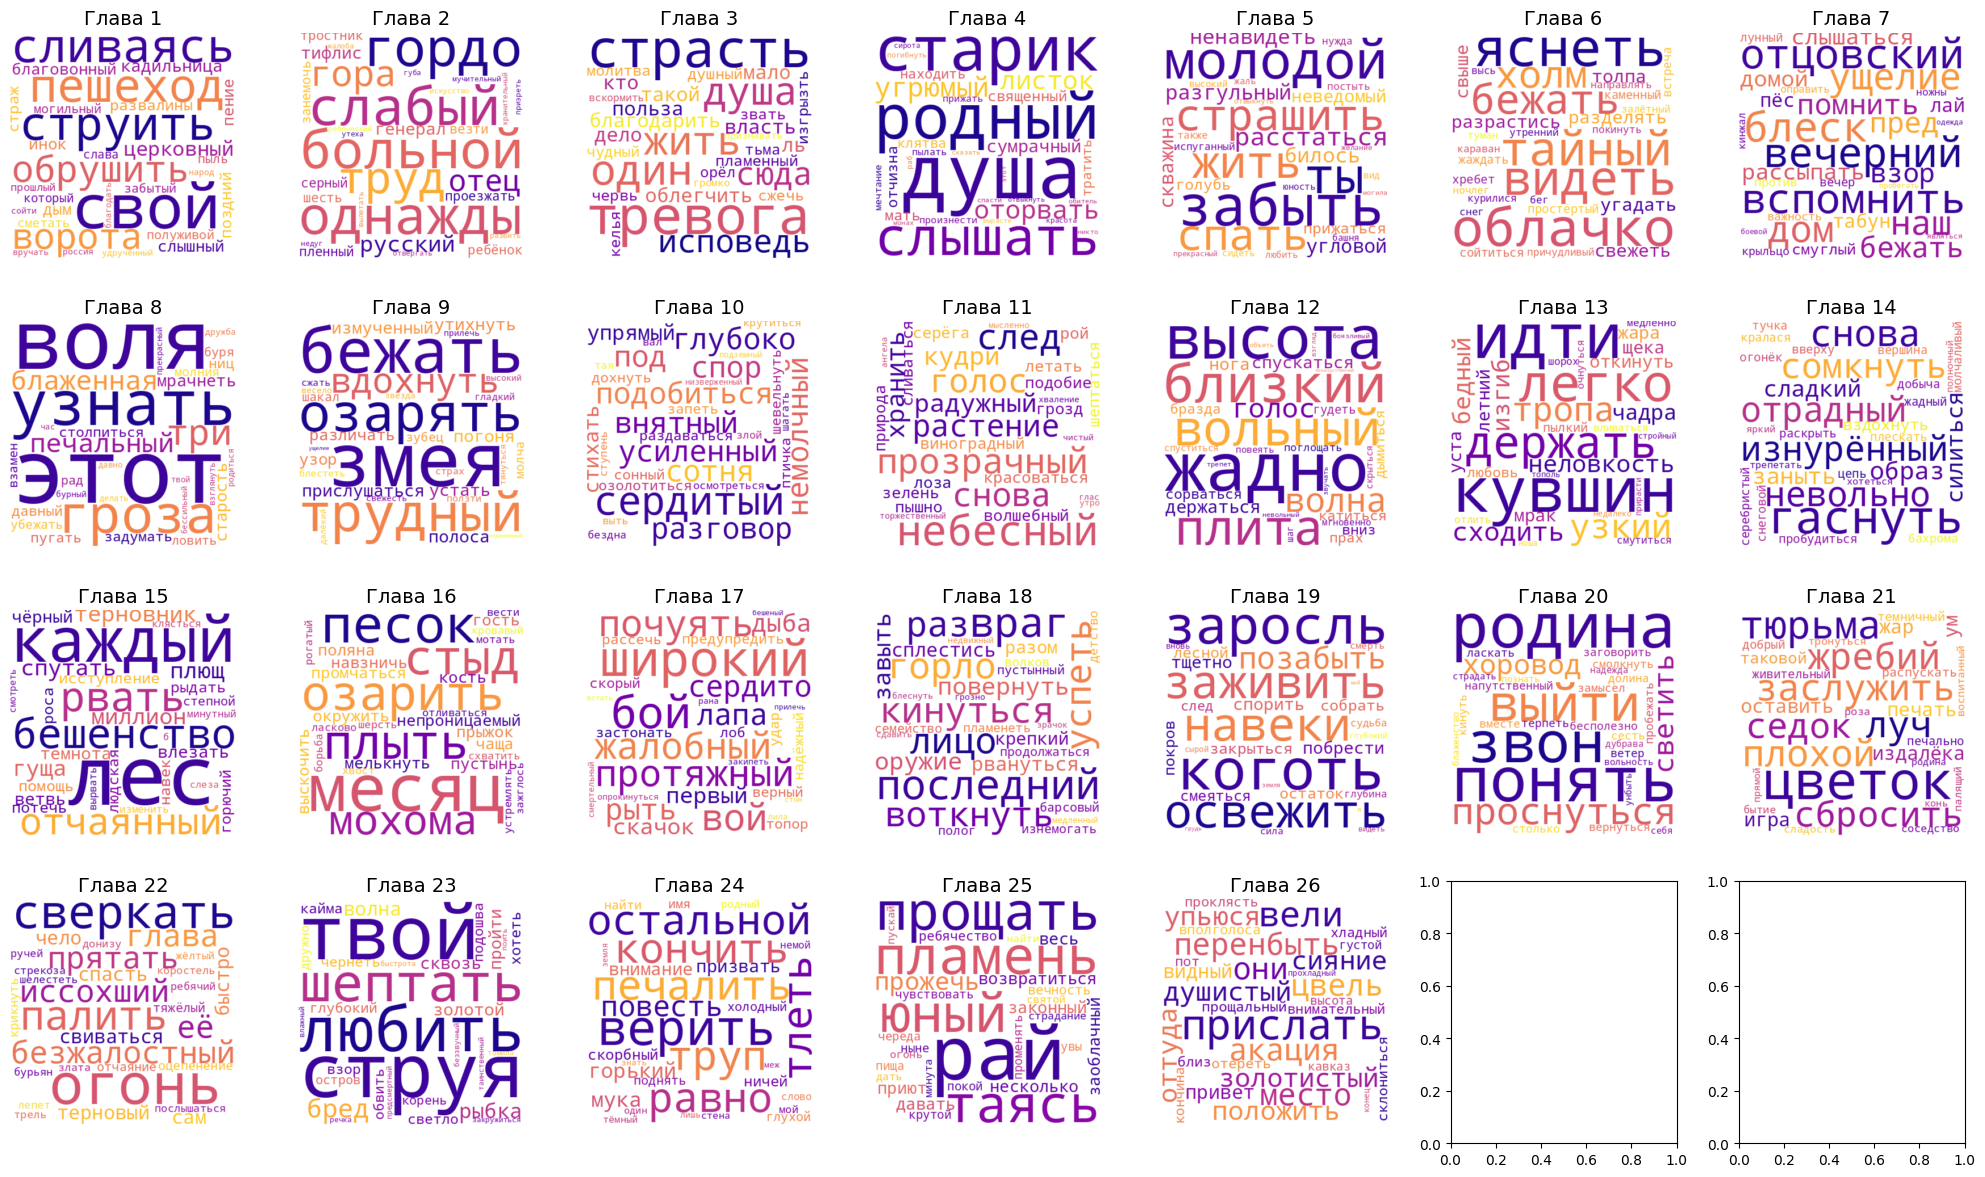

In [144]:
# создаем облака для всех глав

from wordcloud import WordCloud
import matplotlib.pyplot as plt

nrows = 4
ncols = 7
total_plots = nrows * ncols

# Создаем фигуру с сеткой подграфиков
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 12))

# Преобразуем axes в плоский список
axes = axes.flatten()

for i, (ax, chapter_tfidf) in enumerate(zip(axes, tfidf_by_chapter)):
    wordcloud = WordCloud(
        width=400,
        height=400,
        background_color='white',
        colormap='plasma',
        max_words=30,
        random_state=42
    ).generate_from_frequencies(chapter_tfidf)

    ax.imshow(wordcloud, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'Глава {i+1}', fontsize=14)

plt.tight_layout()
plt.show()

Поэма Лермонтова очень маленькая, поэтому большинство слов здесь либо гапаксы, либо повторяются 2-3 раза. Мне кажется, смысла заострять внимания на отдельных главах особо нет, но сделать какие-то выводы на основе общей картины все же можно.

В тексте на протяжении всех глав можно заметить часто повторяющиеся слова, описывающие чувства или эмоции, что характерно для литературы романтизма: «страсть», «тревога», «бешенство», «гордо», «печалить», «страшить» и другие. Иногда встречаются и глаголы передвижения: «бежать», «идти, «выйти», «возвратиться».

На протяжении глав заметен контраст между свободой/пленом («воля» и «тюрьма» в главах 8 и 21), а также между старостью/молодостью («старик» в главе 4, «молодой» в главе 5, «юный» в главе 25). Прослеживается и тематика родины по словам, собственно, «родина», «родный», «отеческий».